In [1]:
# %matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24
MSU_GREEN = "#18453B" 

matplotlib.rc('font', size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
matplotlib.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
matplotlib.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# 1-D Hyrdodynamics Solver

This notebook will lay out a hydrodynamics solver that solves Sod's shock tube.

The results should mimic figures 8.9 and 8.10

Euler's Equation in conservative form:

$$
\mathcal{U}_t + [\textbf{F}(\mathcal{U})]_x = 0
$$

with

$$
\mathcal{U} =
\begin{bmatrix}
\rho \\ \rho u \\ \rho E
\end{bmatrix}

\quad \quad \quad

\textbf{F}(\mathcal{U}) =
\begin{bmatrix}
\rho u \\ \rho uu + p \\ \rho u E + u p
\end{bmatrix}
$$


$E$ is the total energy/mass $$ E = e + \frac{1}{2} u^2,$$ and the equations are closed with a gamma law equation of state, $$p = \rho e(\gamma - 1),$$ where $\gamma$ is the ratio of specific heats for the gas/fluid (for an ideal, monatomic gas, $\gamma = 5/3$). 

For the Sod problem, as described by (8.9.1), we will use $\gamma = 1.4$ and IC of

$$
\begin{align*}
\rho_l = 1 \quad \quad & \quad \quad \rho_r = 1/8 \\
u_l = 0 \quad \quad & \quad \quad u_r = 0 \\
p_l = 1 \quad \quad & \quad \quad p_r = 1/10
\end{align*}
$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#number of ghost cells for Bcs
nghost = 2

# degrees of freedom for solution vector
DOFs_sod = 3

In [4]:
# Initial conditions
def sods_shock_tube_IC(x, gamma):
    if 0 <= x < 0.5:
        rho_init = 1
        u_init = 0
        p_init = 1
    elif 0.5 <= x <= 1:
        rho_init = 1/8
        u_init = 0
        p_init = 1/10
    else:
        print('error in sod IC')
    
    rho = rho_init
    rho_u = rho_init * u_init
    rho_E = p_init/(gamma - 1) + 0.5*rho*u_init*u_init
    U_element = np.array([rho, rho_u, rho_E])
    return U_element


In [5]:
# Outflow BC: 

def fill_ghost_outflow_bc(U,nx):
    # left boundary
    for i in range(DOFs_sod):
        U[i, 0:nghost] = U[i, nghost]
        
        #right boundary
        U[i, nghost+nx:] = U[i, nghost+nx-1]
    
    return U


# print(U_ghost_ic)

# U_bc = fill_ghost_outflow_bc(U_ghost_ic, nx_IC)

# print(U_bc)

In [6]:
# conservative form to primitive form helper function

# takes in U(rho, rho_u, rho_E)
# returns  U(rho, u, p)
def cons_to_prim(U, gamma):
    # grab conservative variables
    rho_cons      = U[0]
    rho_u_cons    = U[1]
    rho_E_cons    = U[2]
    
    # new solution vector to return
    U_prim = np.zeros_like(U)
    
    #pull out primitive variables
    rho_prim = rho_cons
    u_prim   = rho_u_cons/rho_cons
    E_prim   = rho_E_cons/rho_cons
    e_prim   = E_prim - 0.5*u_prim*u_prim
    p_prim   = rho_prim * e_prim * (gamma - 1)

    #assign primitive variables inside new U
    U_prim[0] = rho_prim
    U_prim[1] = u_prim
    U_prim[2] = p_prim
    
    return U_prim

# primitive form to conservative form helper function
# takes in U_prim(rho, u, p)
# returns  U_cons(rho, rho_u, rho_E)
def prim_to_cons(U, gamma):
    # grab conservative variables
    rho_prim      = U[0]
    u_prim        = U[1]
    p_prim        = U[2]
    
    # new solution vector to return
    U_cons = np.zeros_like(U)
    
    #pull out primitive variables
    rho_cons     = rho_prim
    rho_u_cons   = rho_prim*u_prim
    rho_E_cons   = p_prim/(gamma-1) + 0.5*rho_prim*(u_prim**2)
    

    #assign primitive variables inside new U
    U_cons[0] = rho_cons
    U_cons[1] = rho_u_cons
    U_cons[2] = rho_E_cons
    
    return U_cons



In [7]:
# setup function that computes the flux eqn. 8.55

def compute_flux(q, gamma):
    q_prim = cons_to_prim(q, gamma)
    
    rho = q_prim[0]
    u   = q_prim[1]
    p   = q_prim[2]
    
    F = np.zeros_like(q)
    F[0] = rho * u
    F[1] = rho * u*u + p
    F[2] = u*p / (gamma -1) + 0.5*rho *(u*u*u) + u*p
    
    return F


# Riemann Solver

HLL modeled after Carolyn's code

In [8]:
def Riemann_HLL(U_L, U_R, gamma):
    # get primitive form for easier computation
    U_L_prim = cons_to_prim(U_L, gamma)
    U_R_prim = cons_to_prim(U_R, gamma)
    
    rho_L = U_L_prim[0]
    u_L   = U_L_prim[1]
    p_L   = U_L_prim[2]
    
    rho_R = U_R_prim[0]
    u_R   = U_R_prim[1]
    p_R   = U_R_prim[2]
    
    #compute speeds of sound c
    c_L = np.sqrt(gamma*p_L/rho_L)
    c_R = np.sqrt(gamma*p_R/rho_R)

    # determine left and rightmost e.vals
    s_l = min(u_L - c_L, u_R - c_R)
    s_r = max(u_L + c_L, u_R + c_R)
    
    # get the conserved state and fluxes (U_L and U_R are already conservative form)
    
    F_L = compute_flux(U_L, gamma)
    F_R = compute_flux(U_R, gamma)
    
    # determine HLL Flux
    
    if s_l >=0:
        flux = F_L
    elif s_r <=0:
        flux = F_R
    else:
        flux = (s_r * F_L - s_l * F_R + s_l * s_r * (U_R - U_L)) / (s_r - s_l)
    
    return flux
    

# HLLC Riemann solver for Euler

Found Toro's book

In [9]:
def U_star_s(U_s, rho_s, u_s, p_s, E_s, S_s, S_star):
    U_star_s = np.zeros_like(U_s)
    
    factor = rho_s * (S_s - u_s)/(S_s - S_star)
    
    U_star_s[0] = factor
    U_star_s[1] = factor * S_star
    U_star_s[2] = factor * (E_s/rho_s + (S_star - u_s)*(S_star + p_s/(rho_s*(S_s - u_s)))) # (10.39 Toro)
    
    return U_star_s

def Riemann_HLLC(U_L, U_R, gamma):
    # get primitive form for easier computation
    U_L_prim = cons_to_prim(U_L, gamma)
    U_R_prim = cons_to_prim(U_R, gamma)
    
    rho_L = U_L_prim[0]
    u_L   = U_L_prim[1]
    p_L   = U_L_prim[2]
    
    rho_R = U_R_prim[0]
    u_R   = U_R_prim[1]
    p_R   = U_R_prim[2]
    
    #compute speeds of sound c
    c_L = np.sqrt(gamma*p_L/rho_L)
    c_R = np.sqrt(gamma*p_R/rho_R)

    # determine left and rightmost e.vals and S*
    S_L    = min(u_L - c_L, u_R - c_R)
    S_R    = max(u_L + c_L, u_R + c_R)
    S_star = (p_R - p_L + rho_L * u_L * (S_L - u_L) - rho_R * u_R * (S_R - u_R)) / (rho_L*(S_L-u_L) - rho_R*(S_R-u_R)) # (10.37 Toro)
    
    # get the conserved state and fluxes (U_L and U_R are already conservative form)
    F_L = compute_flux(U_L, gamma)
    F_R = compute_flux(U_R, gamma)
    
    # get rho_E_L and rho_E_R for U* computations
    rho_E_L = U_L[2]
    rho_E_R = U_R[2]
    
    # comptue U* and F* for left and right
    U_star_L = U_star_s(U_L, rho_L, u_L, p_L, rho_E_L, S_L, S_star)
    F_star_L = F_L + S_L*(U_star_L - U_L) # (10.38 Toro)
    
    U_star_R = U_star_s(U_R, rho_R, u_R, p_R, rho_E_R, S_R, S_star)
    F_star_R = F_R + S_R*(U_star_R - U_R) # (10.38 Toro)
    
    # determine HLLC Flux
    
    if S_L >=0:
        flux = F_L
    elif (S_L<=0<=S_star):
        flux = F_star_L
    elif (S_star<=0<=S_R):
        flux = F_star_R
    else:
        flux = F_R
    
    return flux
    

In [10]:
def piecewise_constant(U):
    return U, U

In [11]:
def minmod(a, b): #vectorized like Carolyn's so input can be vector valued
    return 0.5 * (np.sign(a) + np.sign(b)) * np.minimum(np.abs(a), np.abs(b))

def compute_interface_states_PLM(U, dx, dt): 
    n = len(U[0])
    U_L = np.zeros_like(U)
    U_R = np.zeros_like(U)

    for i in range(nghost - 1, n - nghost + 1):
        dl = U[:,i+1] - U[:,i]              # forward difference
        dr = U[:,i] - U[:,i-1]              # backward difference

        slope = minmod(dl, dr)

        U_L[:,i] = U[:,i] + 0.5 * slope
        U_R[:,i] = U[:,i] - 0.5 * slope

    return U_L, U_R

def piecewise_linear(U, dx, dt):
    U_L, U_R = compute_interface_states_PLM(U, dx, dt)
    return U_L, U_R

In [12]:

def evolve(U_ghosted, nx, C, t_final, gamma, Riemann, Godunov_type):
    dx = 1.0 / nx

    U = U_ghosted.copy()

    all_solns = [] # movie  stuff
    all_t     = [] # for movie purposes
    t = 0.0
    
    all_solns.append(U[:, nghost:nghost+nx].copy())
    all_t.append(t)
    while t < t_final:
        
        # fill ghost cells with outflow BC
        fill_ghost_outflow_bc(U, nx)
        
        # get the timestep based on the CFL condition, but also make sure we don't step past t_final
        U_prim = cons_to_prim(U[:, nghost:nghost+nx], gamma) #U(rho, u, p)
        c = np.sqrt(gamma*U_prim[2]/U_prim[0]) # sound speed in medium 
        dt = C * dx / np.max(np.abs(U_prim[1]) + c)  # CFL condition based on max velocity in the domain
        dt = min(dt, t_final - t) # adjust final time step to hit t_final exactly
        
        #get the interface states using the specified reconstruction method
        if Godunov_type == 0: # piecewise constant has U_L = U[:, i] and U_R = U[:, i+1], but we have a function anyways
            U_L, U_R = piecewise_constant(U)
        if Godunov_type == 1:
            U_L, U_R = piecewise_linear(U, dx, dt)
        
        # do the update
        F = np.zeros_like(U)
        
        #if Riemann=='HLL':
        # for i in range(nghost-1, nghost+nx):
        #     F[:,i] = Riemann_HLL(U_L[:, i], U_R[:, i+1], gamma) # returns flux of conservative state
    
        #if Riemann=='HLLC':
        for i in range(nghost-1, nghost+nx):
            F[:,i] = Riemann(U_L[:, i], U_R[:, i+1], gamma) # returns flux of conservative state
        
        
        for i in range(nghost, nghost+nx):
            U[:, i] = U[:, i] - (dt/dx) * (F[:, i] - F[:, i-1])
        t += dt
        
        all_solns.append(U[:, nghost:nghost+nx].copy())
        all_t.append(t)

    return U[:, nghost:nghost+nx], all_solns, all_t

In [13]:
def plot_solution(grid, U_Sol, t, gamma, case='Sod', Godonuv_type='Piecewise Constant', Riemann='HLL'):
    '''
    Definition: plots density, pressure, energy, velocity components, and magnetic fields

    Inputs:     grid  : array of x coordinates
                q_sys : conserved variables (ρ, ρu, ρE)^T
                t     : current time
                gamma : adiabatic index
                case : various 1D test cases 

    Outputs:    matplotlib figure showing Euler quantities

    '''

    exact_grid, exact_rho, exact_vex, exact_vey, exact_vez, exact_pre, exact_Bx, exact_By, exact_Bz, exact_E = np.loadtxt(f"exact_solutions/{case}.txt", unpack=True, skiprows=1,)
    
    rho_sol = U_Sol[0]
    rho_u_sol = U_Sol[1]
    rho_E_sol = U_Sol[2]

    u_sol = rho_u_sol / rho_sol
    E_sol = rho_E_sol / rho_sol
    e_sol = E_sol - 0.5*u_sol*u_sol
    p_sol = rho_sol*e_sol*(gamma - 1)
    
    fig, plots = plt.subplots(2, 2, figsize=(18, 10), dpi=300)

    fig.suptitle(f'{case} Shock Tube at t = {t:.2f}')

    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.color'] = 'lavender'
    plt.rcParams['grid.linestyle'] = '-'
    plt.rcParams['grid.linewidth'] = 0.8

    CE = 'k' 

    # Top Left Plot
    plots[0][0].plot(exact_grid, exact_rho, color=CE, linestyle='-', linewidth=2, label='Exact')
    plots[0][0].plot(grid, rho_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5, label=f'{Godonuv_type} \n {Riemann}')
    plots[0][0].set_title('Density')
    plots[0][0].set_xlim([0,1]);# plots[0][0].set_ylim([0.0,1.05]) 
    plots[0][0].legend() 
    
    # Bottom Left Plot
    plots[1][0].plot(exact_grid, exact_pre, color=CE, linestyle='-', linewidth=2)
    plots[1][0].plot(grid, p_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[1][0].set_title('Pressure')
    plots[1][0].set_xlim([0,1]);# plots[0][1].set_ylim([0.0,1.05])

    # Top Left Plot
    plots[0][1].plot(exact_grid, exact_vex, color=CE, linestyle='-', linewidth=2)
    plots[0][1].plot(grid, u_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[0][1].set_title(r'$v_x$')
    plots[0][1].set_xlim([0,1]);# plots[1][0].set_ylim([-0.4,0.8])

    # Bottom Left Plot
    plots[1][1].plot(exact_grid, exact_E, color=CE, linestyle='-', linewidth=2)
    plots[1][1].plot(grid, rho_E_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[1][1].set_title('Total Energy')
    plots[1][1].set_xlim([0,1]);# plots[1][1].set_ylim([-1.7,0.1])

    # plt.savefig(f"{case}.png",dpi=200)

    plt.show()

In [14]:
def movie_maker(grid, all_solns, all_t, gamma, case):
    '''
    Definition: creates a movie of the 1D Euler solution: 
                density, pressure, energy, velocity components, and magnetic fields

    Inputs:     grid      : array of x coordinates
                all_solns : list of conserved variable arrays (ρ, ρu, ρE)^T at each time step
                all_t     : array of all time steps
                gamma : adiabatic index
                case : various 1D test cases 

    Outputs:    movie showing Euler quantities

    '''

    n_steps = len(all_t)

    exact_grid, exact_rho, exact_vex, exact_vey, exact_vez, exact_pre, exact_Bx, exact_By, exact_Bz, exact_E = np.loadtxt(f"exact_solutions/{case}.txt", unpack=True, skiprows=1,)

    # Create a figure and axis for plotting
    fig, plots = plt.subplots(2, 2, figsize=(18, 10), dpi=200)

    def animate(i):
        ''' function to update the plot for each frame  '''

        plots[0][0].clear()
        plots[1][0].clear()
        plots[0][1].clear()
        plots[1][1].clear()

        t = all_t[i]
        U_frame = all_solns[i]  # get the i-th snapshot

        rho_sol   = U_frame[0]
        rho_u_sol = U_frame[1]
        rho_E_sol = U_frame[2]

        u_sol = rho_u_sol / rho_sol
        E_sol = rho_E_sol / rho_sol
        e_sol = E_sol - 0.5*u_sol*u_sol
        p_sol = rho_sol*e_sol*(gamma - 1)
        
        fig.suptitle(f'{case} Shock Tube at t = {t:.3f}')

        plt.rcParams['axes.grid'] = True
        plt.rcParams['grid.color'] = 'lavender'
        plt.rcParams['grid.linestyle'] = '-'
        plt.rcParams['grid.linewidth'] = 0.8

        CE = 'k' 

        # Top Left Plot
        plots[0][0].plot(exact_grid, exact_rho, color=CE, linestyle='-', linewidth=2)
        plots[0][0].plot(grid, rho_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[0][0].set_title('Density')
        plots[0][0].set_xlim([0,1])

        # Bottom Left Plot
        plots[1][0].plot(exact_grid, exact_pre, color=CE, linestyle='-', linewidth=2)
        plots[1][0].plot(grid, p_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[1][0].set_title('Pressure')
        plots[1][0].set_xlim([0,1])

        # Top Right Plot
        plots[0][1].plot(exact_grid, exact_vex, color=CE, linestyle='-', linewidth=2)
        plots[0][1].plot(grid, u_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[0][1].set_title(r'$v_x$')
        plots[0][1].set_xlim([0,1])

        # Bottom Right Plot
        plots[1][1].plot(exact_grid, exact_E, color=CE, linestyle='-', linewidth=2)
        plots[1][1].plot(grid, rho_E_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[1][1].set_title('Total Energy')
        plots[1][1].set_xlim([0,1])

    # Create the animation using matplotlib's FuncAnimation
    ani = animation.FuncAnimation(fig, animate, frames=n_steps, interval=1, blit=False)
    # Save the animation as a video file
    ani.save(f"{case}.gif", writer='pillow', fps=30, dpi=100)

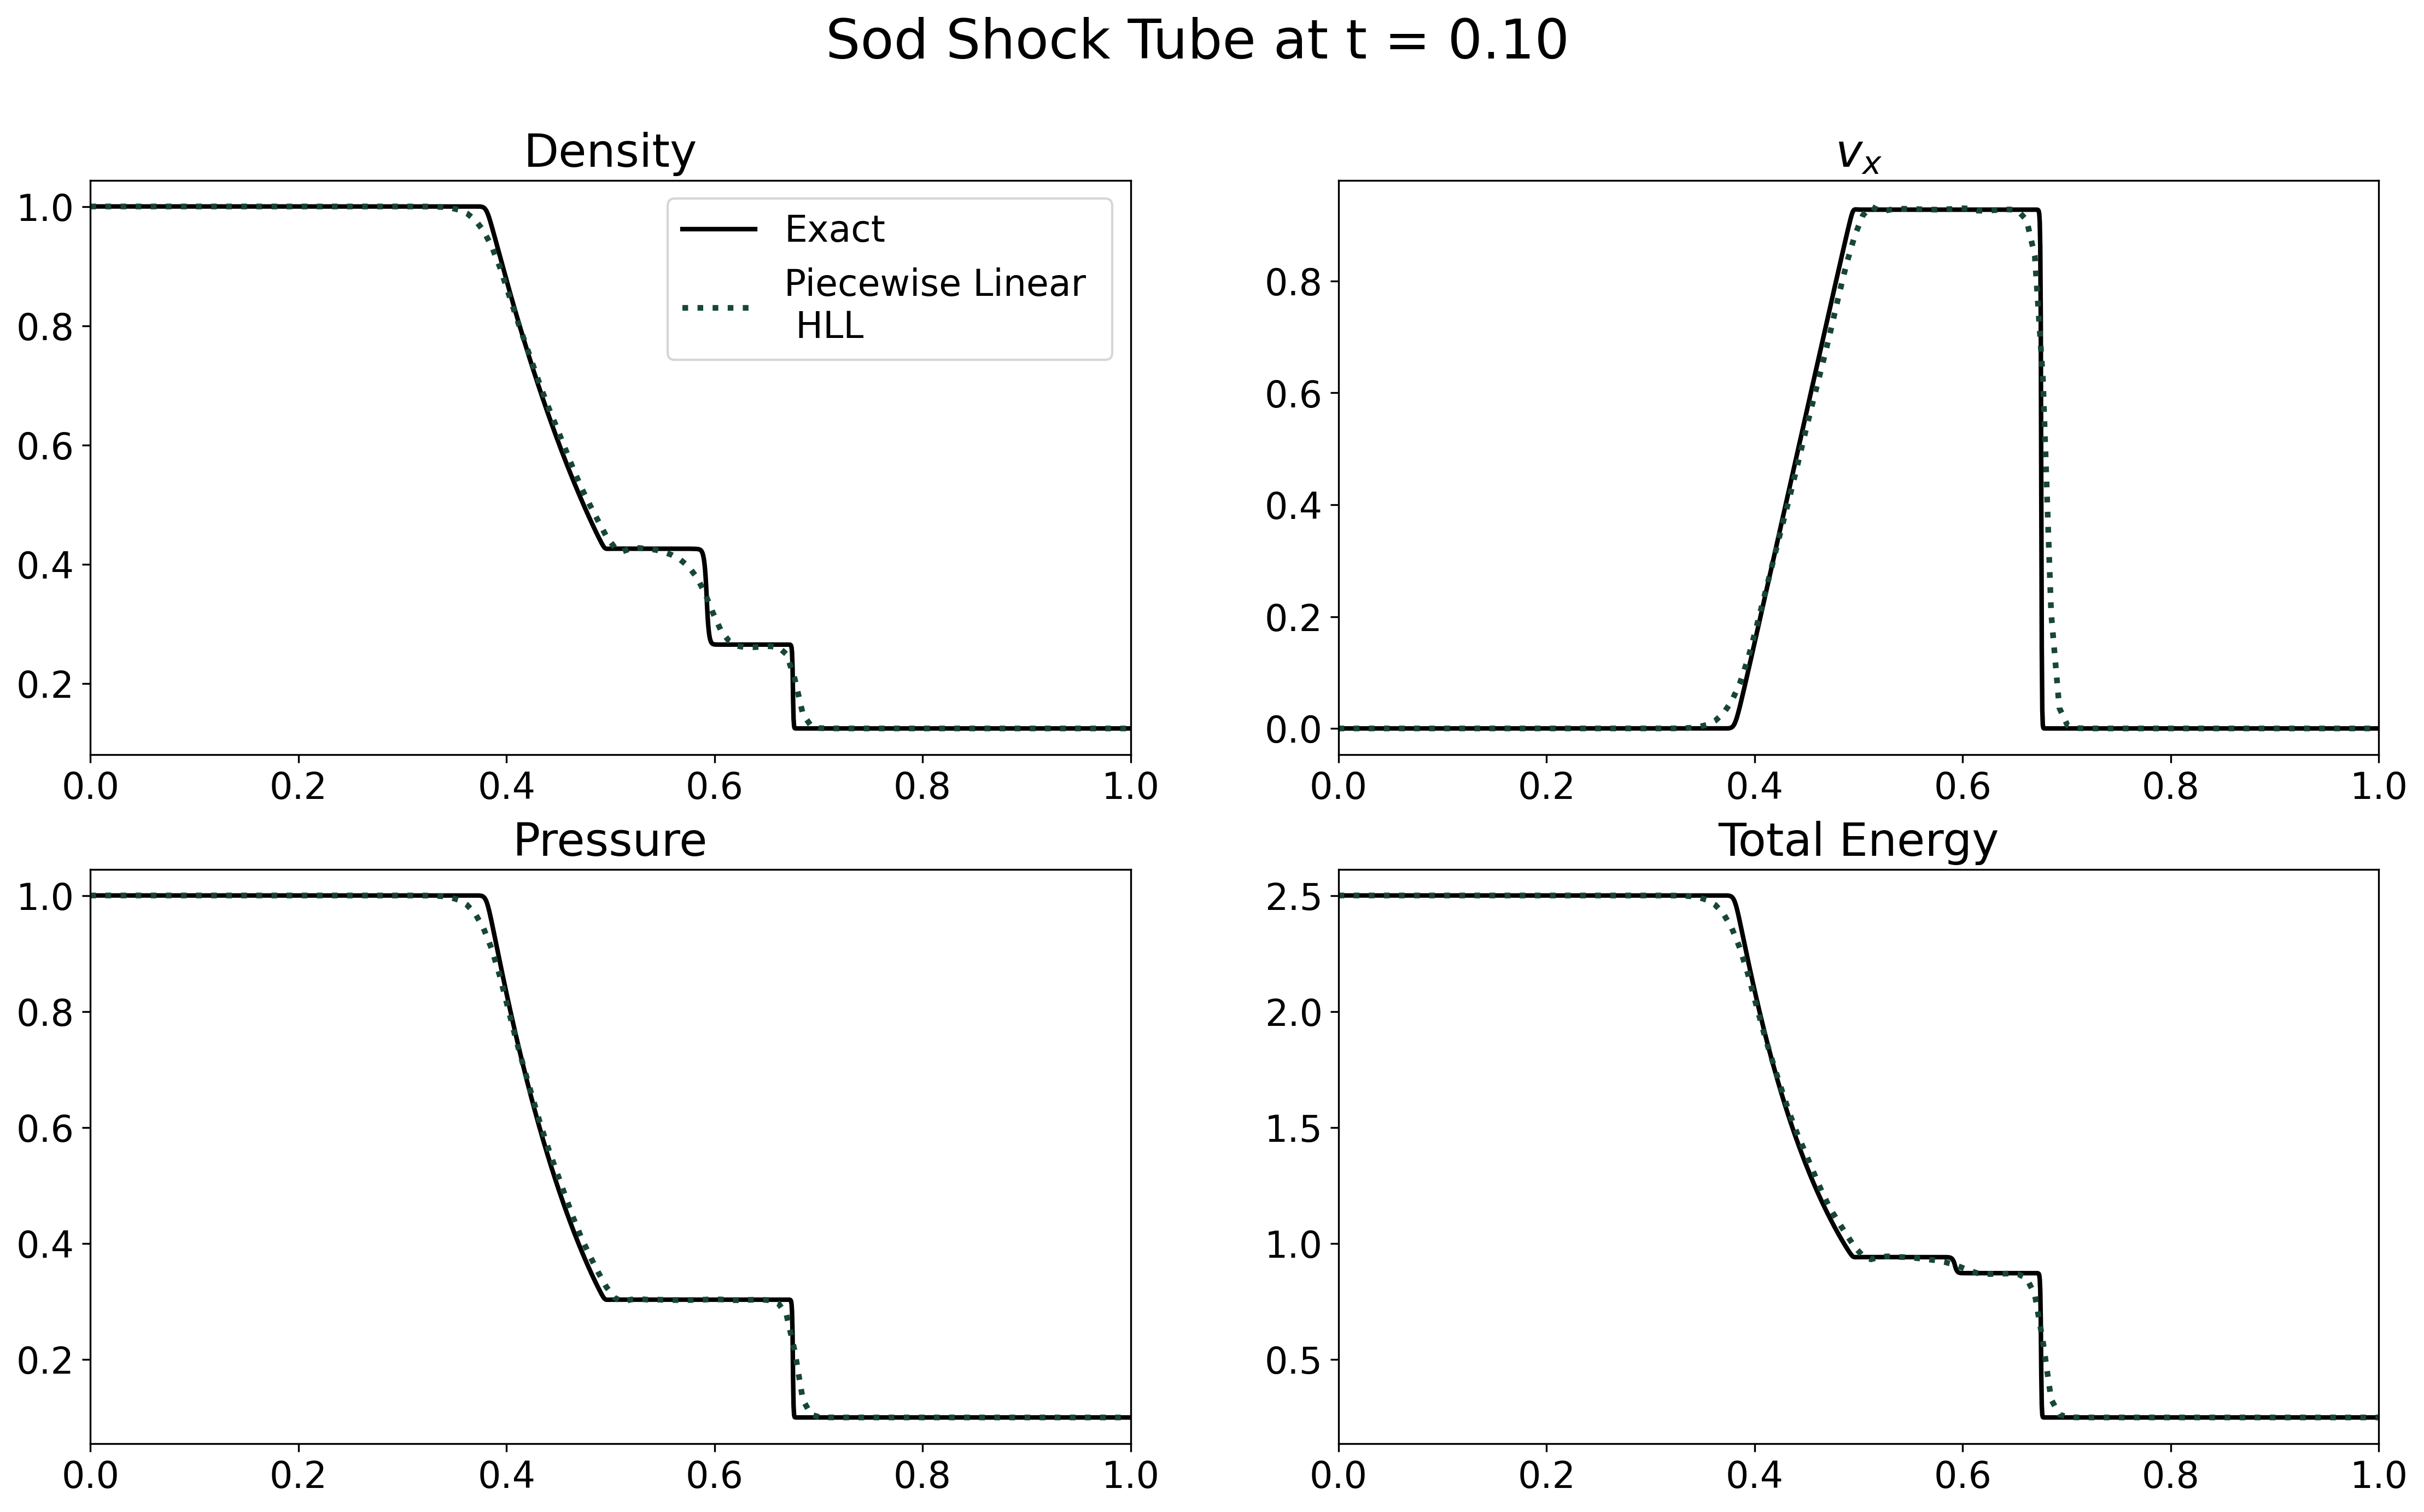

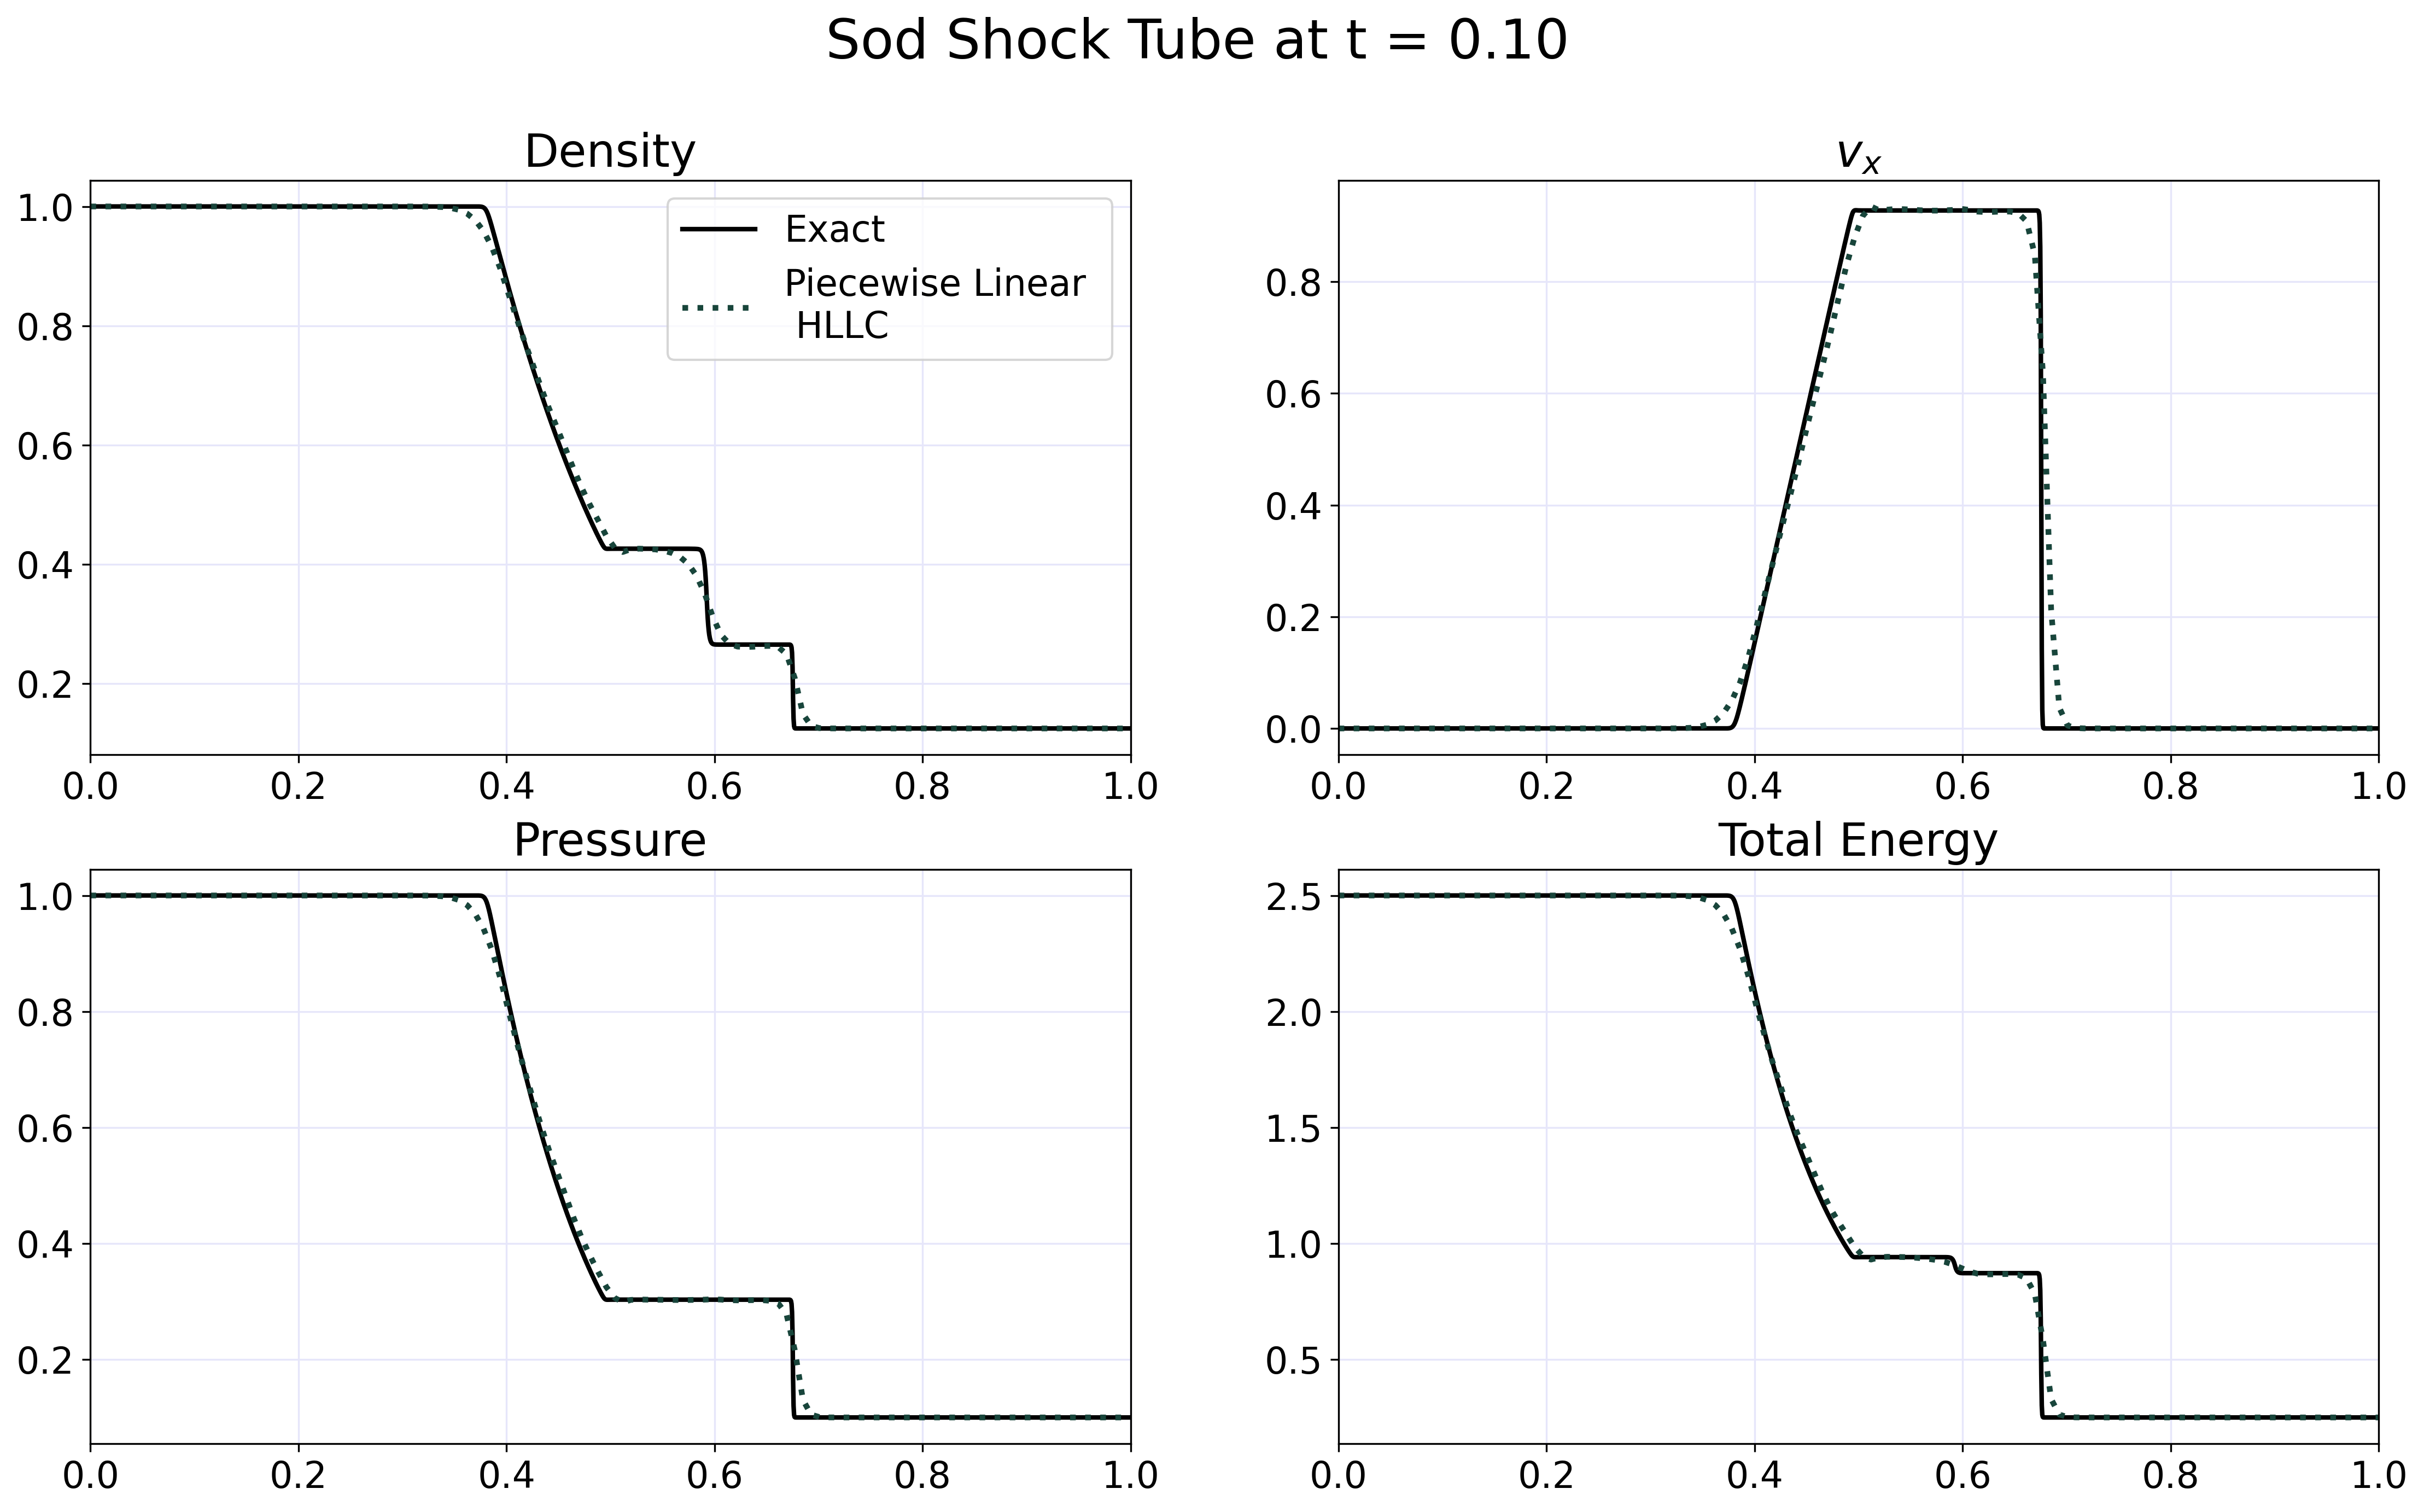

In [15]:
# Sod problem setting up variables and visualizing

DOFs_sod = 3
nx = 128
dx = 1/nx
C = 0.1
gamma = 1.4
tf = 0.1

X = np.linspace(0,1, nx)

#need vector valued solution vector U = (rho, rho u, rho E)
U_IC_Sod = np.array([sods_shock_tube_IC(x, gamma) for x in X]) # shape (nx, DOF)
U_IC_Sod = U_IC_Sod.T # shape (DOF, nx)
U_ghost_IC_Sod = np.zeros((DOFs_sod, nx + 2*nghost)) #shape (DOF, nx+ghosts)
U_ghost_IC_Sod[:, nghost:nghost+nx] = U_IC_Sod # ghosted vector able to have BCs


#U_Sol_Sod_g0, all_solns_Sod_g0, all_t_Sod_g0 = evolve(U_ghost_IC_Sod, nx, C, tf, gamma, Godunov_type=0)
U_Sol_Sod_g1_HLL, all_solns_Sod_g1_HLL, all_t_Sod_g1_HLL    = evolve(U_ghost_IC_Sod, nx, C, tf, gamma, Riemann_HLL, Godunov_type=1)
U_Sol_Sod_g1_HLLC, all_solns_Sod_g1_HLLC, all_t_Sod_g1_HLLC = evolve(U_ghost_IC_Sod, nx, C, tf, gamma, Riemann_HLLC, Godunov_type=1)


plot_solution(X, U_Sol_Sod_g1_HLL, tf, gamma, 'Sod', 'Piecewise Linear', 'HLL')
plot_solution(X, U_Sol_Sod_g1_HLLC, tf, gamma, 'Sod', 'Piecewise Linear', 'HLLC')




# $\Downarrow$ Make a Movie $\Downarrow$
Takes ~10 min to run for n_points = 1024

In [16]:
#movie_maker(X, all_solns_Sod_g1, all_t_Sod_g1, gamma, 'Sod')